# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [ ]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

## Carregue os dados

In [ ]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv('/datasets/megaline_users.csv')
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')

## Prepare os dados

## Planos

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print('Mostrando as informações do DataFrame')
df_plans.info()

Mostrando as informações do DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Imprima uma amostra de dados dos planos
print('Mostrando o DataFrame plans com as 5 primeiras linhas')
print(df_plans.head())

Mostrando o DataFrame plans com as 5 primeiras linhas
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


**Análise do DataFrame df_plans**
- O DataFrame plans contém 2 linhas e 8 colunas, representando os dois planos.
- Não há valores ausentes (non-null count é 2 para todas as colunas).
- Os tipos de dados (int64, float64, object) parecem apropriados para cada coluna.
- Observa-se que o volume de dados incluso no pacote está em megabytes (mb_per_month_included). Para facilitar os cálculos futuros de excedente (que é cobrado por GB), será necessário converter essa coluna ou criar uma nova em gigabytes.


## Corrija os dados

In [ ]:
print('Confirmação de não ausentes')
print(df_plans.isna().sum())
# Convertendo todos da coluna 'plan_name' em minúsculas
df_plans['plan_name'] = df_plans['plan_name'].str.lower()
print('Verificação se existe duplicados')
print(df_plans.duplicated().sum())

Confirmação de não ausentes
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
Verificação se existe duplicados
0


## Enriqueça os dados

In [ ]:
# Criar uma nova coluna e converter MB para GB para facilitar cálculos futuros
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024

## Usuários

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprima uma amostra de dados dos usuários
print(df_users.head(10))

   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little   19  San Jose-Sunnyvale-Santa Clara, CA MSA   

     reg_date      plan  churn_date  
0  2018-12-24  ultimate         NaN  
1  2018-08-13      surf         

- O DataFrame tem 500 entradas, como esperado.
- A coluna churn_date possui muitos valores ausentes (466). Conforme a descrição do projeto, isso indica que a maioria dos clientes ainda estava com o plano ativo na data da extração dos dados. Isso é normal e não configura um problema a ser corrigido, apenas uma observação.
- As colunas reg_date e churn_date estão como object. Isso precisa ser corrigido.
- A amostra de dados mostra que a coluna city contém nomes de regiões metropolitanas completos, como "Atlanta-Sandy Springs-Roswell, GA MSA". Isso será útil para identificar a região de NY-NJ.

### Corrija os dados

In [ ]:
print('Verificando valores ausentes')
print(df_users.isna().sum())
# Convertendo colunas de texto para minúsculas
df_users['first_name'] = df_users['first_name'].str.lower()
df_users['last_name'] = df_users['last_name'].str.lower()
df_users['city'] = df_users['city'].str.lower()
df_users['plan'] = df_users['plan'].str.lower()

# Verificando valores duplicados
print('------------------------------------')
print('Verificando valores duplicados')
print(df_users.duplicated().sum())

Verificando valores ausentes
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64
------------------------------------
Verificando valores duplicados
0


### Enriqueça os dados

In [ ]:
# Convertendo as colunas 'reg_date' e 'churn_date' para datetime
# Extraindo o mês de registro para entender quando o usuário começou a gerar receita
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
df_users['month'] = df_users['reg_date'].dt.month
# Criando uma coluna booleana para identificar quem é da região NY-NJ
# Isso será essencial para o seu teste de hipótese final
df_users['is_ny_nj'] = df_users['city'].str.contains('ny-nj', case=False)
# Imprimindo o DataFrame
print(df_users)

     user_id first_name   last_name  age  \
0       1000   anamaria       bauer   45   
1       1001     mickey   wilkerson   28   
2       1002     carlee     hoffman   36   
3       1003   reynaldo     jenkins   52   
4       1004    leonila    thompson   40   
..       ...        ...         ...  ...   
495     1495      fidel      sharpe   67   
496     1496      ariel    shepherd   49   
497     1497      donte     barrera   49   
498     1498       scot  williamson   51   
499     1499      shena     dickson   37   

                                          city   reg_date      plan  \
0        atlanta-sandy springs-roswell, ga msa 2018-12-24  ultimate   
1              seattle-tacoma-bellevue, wa msa 2018-08-13      surf   
2         las vegas-henderson-paradise, nv msa 2018-10-21      surf   
3                                tulsa, ok msa 2018-01-28      surf   
4              seattle-tacoma-bellevue, wa msa 2018-05-23      surf   
..                                         ..

## Chamadas

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprima uma amostra de dados das chamadas
print(df_calls.head(10))

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
5  1000_388     1000  2018-12-31      2.20
6  1000_510     1000  2018-12-27      5.75
7  1000_521     1000  2018-12-28     14.18
8  1000_530     1000  2018-12-28      5.77
9  1000_544     1000  2018-12-26      4.40


**Análise:**
- O DataFrame possui 137.735 registros de chamadas.
- Não há valores ausentes.
- A coluna call_date está como object e precisa ser convertida para datetime.
- A coluna duration está como float. De acordo com as regras da Megaline, a duração deve ser arredondada para cima (ceil) e tratada como minutos inteiros.


### Corrija os dados

In [ ]:
# Convertendo a coluna call_date para o tipo datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

### Enriqueça os dados

In [ ]:
# Arredondando os minutos para cima usando np.ceil e convertendo para inteiro
df_calls['duration'] = np.ceil(df_calls['duration']).astype(int)
# Criando a coluna do mês para facilitar a agregação mensal depois
df_calls['month'] = df_calls['call_date'].dt.month
print(df_calls)

              id  user_id  call_date  duration  month
0        1000_93     1000 2018-12-27         9     12
1       1000_145     1000 2018-12-27        14     12
2       1000_247     1000 2018-12-27        15     12
3       1000_309     1000 2018-12-28         6     12
4       1000_380     1000 2018-12-30         5     12
...          ...      ...        ...       ...    ...
137730  1499_199     1499 2018-11-21         9     11
137731  1499_200     1499 2018-10-20        11     10
137732  1499_201     1499 2018-09-21         9      9
137733  1499_202     1499 2018-10-10         1     10
137734  1499_203     1499 2018-12-29        14     12

[137735 rows x 5 columns]


## Mensagens

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprima uma amostra dos dados das mensagens
print(df_messages.head(10))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28


**Análise**
- O DataFrame df_messages não possui valores ausentes e/ou nulos.
- Iremos corrigir a coluna 'message_date' de object para datetime.
- E extrairemos o mês da mensagem de texto

### Corrija os dados

In [ ]:
# Verificando se ha duplicados na coluna chave
print(df_messages['id'].duplicated().sum())

# Convertendo a coluna message_date para tipo datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

0


### Enriqueça os dados

In [ ]:
# Criando a coluna month extrando da coluna message_date
df_messages['month'] = df_messages['message_date'].dt.month
# Imprimindo amostra dos dos dados atualizados
print(df_messages.head(10))

         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12
5  1000_346     1000   2018-12-29     12
6  1000_386     1000   2018-12-30     12
7  1000_413     1000   2018-12-31     12
8  1000_502     1000   2018-12-27     12
9  1000_525     1000   2018-12-28     12


## Internet

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
#  Imprima uma amostra de dados para o tráfego da internet
print(df_internet.head(10))

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92


**Analise**
- Verificar duplicados pela chave id
- Converter a coluna 'session_date' de object para datetime.
- Criar uma coluna month para analise futura.

### Corrija os dados

In [ ]:
# Verificando se há duplicdos
print('Quantidade de duplicatos:')
print(df_internet['id'].duplicated().sum())
# Convertendo a coluna 'session_date' para o formato datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

Quantidade de duplicatos:
0


### Enriqueça os dados

In [ ]:
# Criando a coluna month extraindo da coluna df_internet
df_internet['month'] = df_internet['session_date'].dt.month

## Estude as condições dos planos

In [ ]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
print(df_plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


## Agregue os dados por usuário

In [ ]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
calls_month = df_calls.groupby(['user_id', 'month']).agg(calls=('id', 'count')).reset_index()
print(calls_month)

      user_id  month  calls
0        1000     12     16
1        1001      8     27
2        1001      9     49
3        1001     10     65
4        1001     11     64
...       ...    ...    ...
2253     1498     12     39
2254     1499      9     41
2255     1499     10     53
2256     1499     11     45
2257     1499     12     65

[2258 rows x 3 columns]


In [ ]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
minutes_month = df_calls.groupby(['user_id', 'month']).agg(minutes = ('duration', 'sum')).reset_index()
print(minutes_month)

      user_id  month  minutes
0        1000     12      124
1        1001      8      182
2        1001      9      315
3        1001     10      393
4        1001     11      426
...       ...    ...      ...
2253     1498     12      339
2254     1499      9      346
2255     1499     10      385
2256     1499     11      308
2257     1499     12      496

[2258 rows x 3 columns]


In [ ]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
menssage_month = df_messages.groupby(['user_id', 'month']).agg(menssages = ('id', 'count')).reset_index()
print(menssage_month)

      user_id  month  menssages
0        1000     12         11
1        1001      8         30
2        1001      9         44
3        1001     10         53
4        1001     11         36
...       ...    ...        ...
1801     1496      9         21
1802     1496     10         18
1803     1496     11         13
1804     1496     12         11
1805     1497     12         50

[1806 rows x 3 columns]


In [ ]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
internet_month = df_internet.groupby(['user_id', 'month']).agg(mb_used= ('mb_used', 'sum')).reset_index()
print(internet_month)

      user_id  month   mb_used
0        1000     12   1901.47
1        1001      8   6919.15
2        1001      9  13314.82
3        1001     10  22330.49
4        1001     11  18504.30
...       ...    ...       ...
2272     1498     12  23137.69
2273     1499      9  12984.76
2274     1499     10  19492.43
2275     1499     11  16813.83
2276     1499     12  22059.21

[2277 rows x 3 columns]


In [ ]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
merge_all = calls_month.merge(minutes_month, on= ['user_id', 'month'], how= 'outer')
merge_all = merge_all.merge(menssage_month, on= ['user_id', 'month'], how= 'outer')
merge_all = merge_all.merge(internet_month, on= ['user_id', 'month'], how= 'outer')
# Preencher valores nulos com 0 (significa que o usuário não usou o serviço naquele mês)
merge_all = merge_all.fillna(0)
# Imprimindo
print(merge_all)

      user_id  month  calls  minutes  menssages   mb_used
0        1000     12   16.0    124.0       11.0   1901.47
1        1001      8   27.0    182.0       30.0   6919.15
2        1001      9   49.0    315.0       44.0  13314.82
3        1001     10   65.0    393.0       53.0  22330.49
4        1001     11   64.0    426.0       36.0  18504.30
...       ...    ...    ...      ...        ...       ...
2288     1349     12    0.0      0.0       61.0  13039.91
2289     1361      5    0.0      0.0        2.0   1519.69
2290     1482     10    0.0      0.0        2.0      0.00
2291     1108     12    0.0      0.0        0.0    233.17
2292     1311      6    0.0      0.0        0.0   1498.83

[2293 rows x 6 columns]


In [ ]:
# Adicione as informações sobre o plano
user_plan_info = df_users[['user_id', 'plan', 'is_ny_nj']]
# Fazendo o merge com o DataFrame agregado
merge_all = merge_all.merge(user_plan_info, on= 'user_id', how= 'left')
# Imprimindo o resultado
print(merge_all)

      user_id  month  calls  minutes  menssages   mb_used      plan  is_ny_nj
0        1000     12   16.0    124.0       11.0   1901.47  ultimate     False
1        1001      8   27.0    182.0       30.0   6919.15      surf     False
2        1001      9   49.0    315.0       44.0  13314.82      surf     False
3        1001     10   65.0    393.0       53.0  22330.49      surf     False
4        1001     11   64.0    426.0       36.0  18504.30      surf     False
...       ...    ...    ...      ...        ...       ...       ...       ...
2288     1349     12    0.0      0.0       61.0  13039.91      surf     False
2289     1361      5    0.0      0.0        2.0   1519.69      surf     False
2290     1482     10    0.0      0.0        2.0      0.00  ultimate      True
2291     1108     12    0.0      0.0        0.0    233.17  ultimate     False
2292     1311      6    0.0      0.0        0.0   1498.83  ultimate     False

[2293 rows x 8 columns]


In [ ]:
def calculate_monthly_revenue(row):
    # Extrai o nome do plano da linha atual (ex: 'surf' ou 'ultimate')
    plan_name = row['plan']
    # Busca no DataFrame df_plans a linha que corresponde ao plano do usuário
    # df_plans[df_plans['plan_name'] == plan_name] retorna um DataFrame filtrado
    # .iloc[0] pega a primeira (e única) linha como uma Series
    plan_details = df_plans[df_plans['plan_name'] == plan_name].iloc[0]
    # Valores fixos do plano (cobrados independentemente do uso)
    monthly_fee = plan_details['usd_monthly_pay']  # Taxa mensal em dólares
    # Limites inclusos no pacote (não pagam nada até esses valores)
    incl_minutes = plan_details['minutes_included']    # Minutos inclusos
    incl_messages = plan_details['messages_included']  # Mensagens inclusas
    incl_gb = plan_details['gb_per_month_included']    # GB inclusos (convertido de MB)
    # Preços por unidade extra (após exceder o pacote)
    price_extra_minute = plan_details['usd_per_minute']  # Preço por minuto extra
    price_extra_message = plan_details['usd_per_message']  # Preço por mensagem extra
    price_extra_gb = plan_details['usd_per_gb']  # Preço por GB extra
    # Fórmula: minutos_usados - minutos_inclusos, mas nunca negativo
    # max(0, valor) garante que se o usuário não excedeu, o extra é 0
    extra_minutes = max(0, row['minutes'] - incl_minutes)
    # Mesma lógica: mensagens_usadas - mensagens_inclusas, mínimo 0
    extra_messages = max(0, row['menssages'] - incl_messages)

    # REGRA IMPORTANTE DA MEGALINE:
    # 1. O consumo de internet é medido em MB nos dados brutos
    # 2. A cobrança é por GB, com arredondamento PARA CIMA do total mensal
    # 3. 1 GB = 1024 MB
    # Converte MB para GB e arredonda para cima (ceil)
    # Exemplo: 1500 MB / 1024 = 1.465 GB -> arredonda para 2 GB
    gb_used = np.ceil(row['mb_used'] / 1024)
    # Calcula GB extras: GB_usados - GB_inclusos, mínimo 0
    extra_gb = max(0, gb_used - incl_gb)
    # Fórmula: taxa_fixa + (min_extras * preco_min) + (msg_extras * preco_msg) + (gb_extras * preco_gb)
    total_revenue = (monthly_fee +                    # Taxa base do plano
                     extra_minutes * price_extra_minute +   # Custo dos minutos extras
                     extra_messages * price_extra_message + # Custo das mensagens extras
                     extra_gb * price_extra_gb)             # Custo dos GB extras

    return total_revenue
# Aplicando a função criada
# axis=1 significa que a função será aplicada a cada LINHA (não coluna)
merge_all['revenue'] = merge_all.apply(calculate_monthly_revenue, axis=1)
# Imprimindo os resultados
print("Exemplos de receita mensal calculada para alguns usuários:")
print("=" * 60)
print(merge_all[['user_id', 'month', 'plan', 'revenue']].head(10))
print("=" * 60)

# ===== ESTATÍSTICAS BÁSICAS PARA VERIFICAR =====
print("\nResumo estatístico da receita calculada:")
print(f"Receita média: ${merge_all['revenue'].mean():.2f}")
print(f"Receita mínima: ${merge_all['revenue'].min():.2f}")
print(f"Receita máxima: ${merge_all['revenue'].max():.2f}")

Exemplos de receita mensal calculada para alguns usuários:
   user_id  month      plan  revenue
0     1000     12  ultimate    70.00
1     1001      8      surf    20.00
2     1001      9      surf    20.00
3     1001     10      surf    90.09
4     1001     11      surf    60.00
5     1001     12      surf    60.00
6     1002     10      surf    20.00
7     1002     11      surf    60.00
8     1002     12      surf    20.00
9     1003     12      surf   158.12

Resumo estatístico da receita calculada:
Receita média: $64.35
Receita mínima: $20.00
Receita máxima: $590.37


## Estude o comportamento do usuário

Nesta seção, realizaremos uma análise exploratória completa do comportamento dos usuários, comparando os planos Surf e Ultimate em três categorias: chamadas, mensagens e internet.

Para cada serviço, vamos:
1. Calcular estatísticas descritivas (média, mediana, variância, desvio padrão)
2. Criar visualizações (gráficos de linhas, histogramas e boxplots)
3. Comparar o comportamento entre os planos
4. Extrair conclusões sobre qual plano é mais adequado para cada tipo de uso

O objetivo é entender se os usuários do plano Ultimate realmente utilizam os benefícios do plano ou se o plano Surf é suficiente para a maioria dos clientes.


### Chamadas

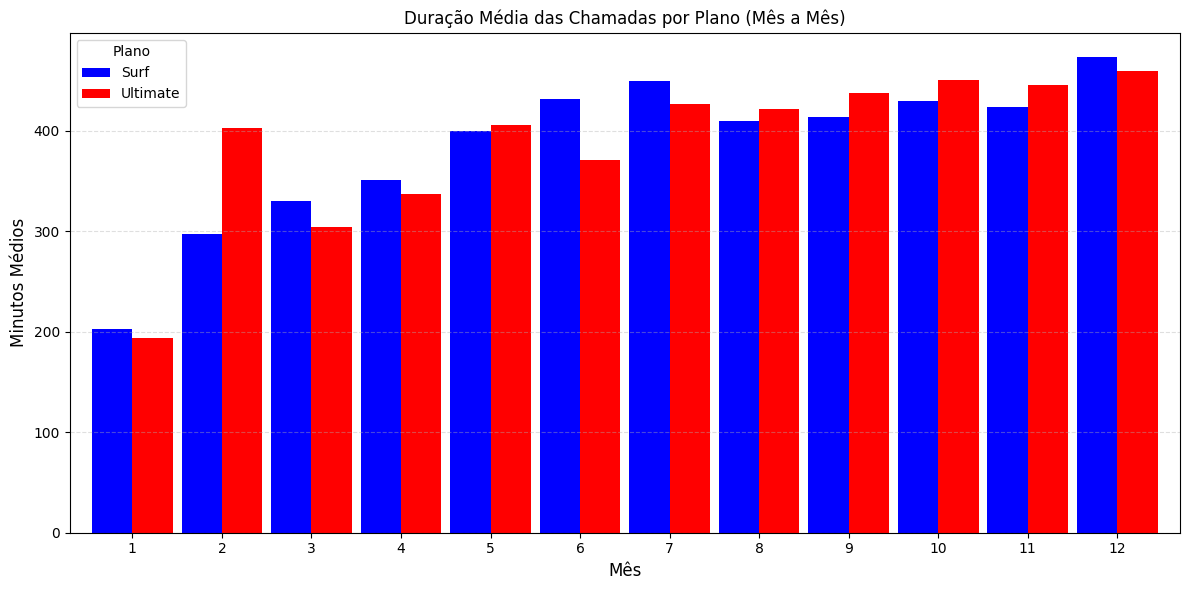

In [ ]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
# Calculamos a média da coluna 'minutes' por mês e plano
duration_mean_calls = merge_all.groupby(['month', 'plan'])['minutes'].mean().reset_index()
# Transformamos os planos em colunas para facilitar a plotagem lado a lado.
pivot_duration = duration_mean_calls.pivot(index='month', columns='plan', values='minutes')

# Criamos o gráfico de barras (conforme solicitado no enunciado do projeto).
# Escolhemos cores com bom contraste para uma análise fria e clara.
ax = pivot_duration.plot(kind='bar', figsize=(12, 6), width=0.9, color=['blue', 'red'])

# Criando titulo e rótulos
plt.title('Duração Média das Chamadas por Plano (Mês a Mês)')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Minutos Médios', fontsize=12)

# Garantimos que todos os meses apareçam e fiquem na horizontal para leitura rápida
plt.xticks(rotation=0)

# Adicionamos a legenda e uma grade suave para referência de valores
plt.legend(title='Plano', labels=['Surf', 'Ultimate'])
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 5. Ajuste de layout
plt.tight_layout()

# Exibição do gráfico
plt.show()

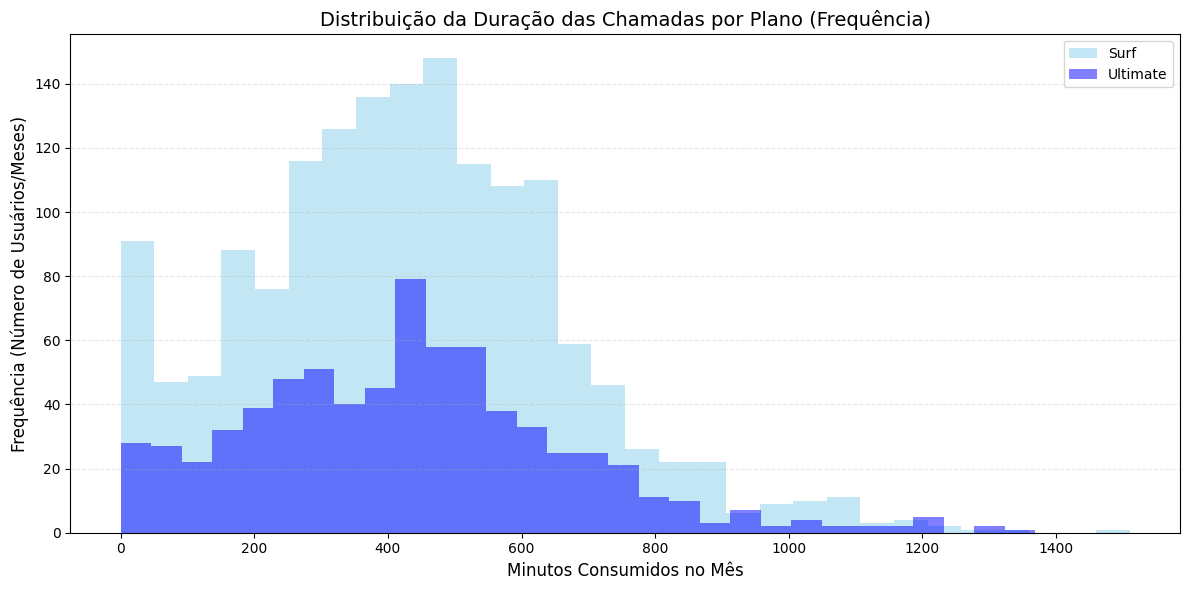

In [ ]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
# Extraímos apenas a coluna 'minutes' para cada categoria.
surf_minutes = merge_all[merge_all['plan'] == 'surf']['minutes']
ultimate_minutes = merge_all[merge_all['plan'] == 'ultimate']['minutes']

# Criação da figura
plt.figure(figsize=(12, 6))
# Plotagem dos Histogramas
# label: para identificarmos qual cor pertence a qual plano na legenda.
plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf', color='skyblue')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='blue')

# Criando titulo e rótulos
plt.title('Distribuição da Duração das Chamadas por Plano (Frequência)', fontsize=14)
plt.xlabel('Minutos Consumidos no Mês', fontsize=12)
plt.ylabel('Frequência (Número de Usuários/Meses)', fontsize=12)

# Adicionamos a legenda para diferenciar os planos
plt.legend()
# Adicionamos uma grade suave para facilitar a leitura das frequências
plt.grid(axis='y', linestyle='--', alpha=0.3)
# Ajuste de layout
plt.tight_layout()
# Exibição do gráfico
plt.show()

In [ ]:
# Calcule a média e a variância da duração mensal das chamadas
# Calculando as estatísticas agrupadas por plano.
# Usamos o método .agg() para aplicar a média (.mean()) e a variância (.var()) simultaneamente.
# Adicionei também o desvio padrão (.std()), pois ele é a raiz quadrada da variância
# e é mais fácil de interpretar por estar na mesma unidade dos minutos.
stats_minutes = merge_all.groupby('plan')['minutes'].agg(['mean', 'var', 'std']).reset_index()

# Renomeando as colunas para um formato profissional de relatório técnico.
stats_minutes.columns = ['Plano', 'Média de Minutos', 'Variância', 'Desvio Padrão']

# Exibindo os resultados para análise de faturamento.
# Analise com frieza: Uma variância alta indica que os usuários têm comportamentos
# muito diferentes entre si, o que torna a previsão de receita mais instável.
print("Estatísticas Descritivas de Consumo (Minutos):")
print(stats_minutes)

Estatísticas Descritivas de Consumo (Minutos):
      Plano  Média de Minutos     Variância  Desvio Padrão
0      surf        428.749523  54968.279461     234.453150
1  ultimate        430.450000  57844.464812     240.508762


<Figure size 1000x700 with 0 Axes>

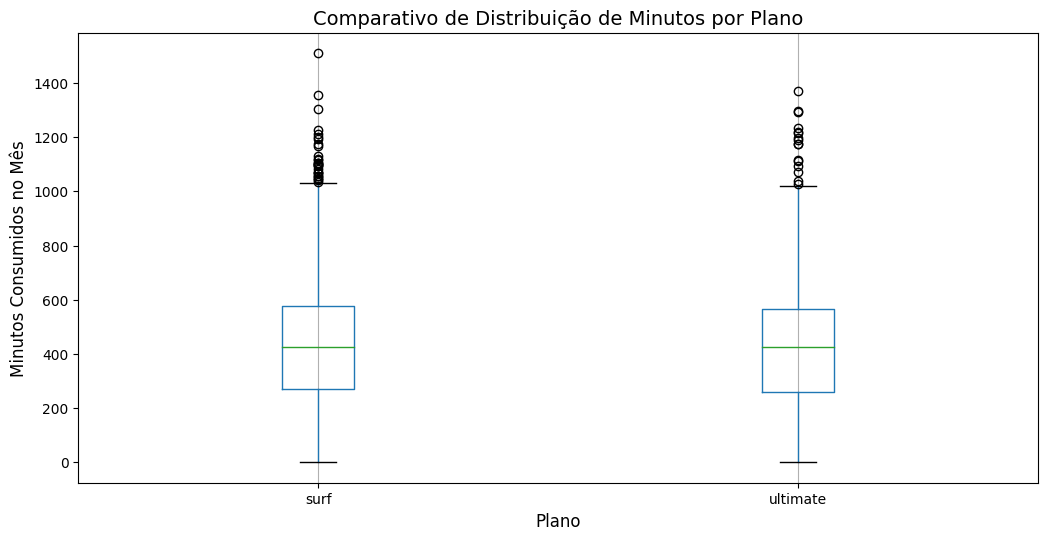

In [ ]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
# Criando a figura do gráfico.
plt.figure(figsize=(10, 7))

# Gerando o Boxplot.
merge_all.boxplot(column='minutes', by='plan', figsize=(12, 6))

# Customização e Limpeza Visual.
plt.title('Comparativo de Distribuição de Minutos por Plano', fontsize=14)
plt.suptitle('')
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Minutos Consumidos no Mês', fontsize=12)

# Adicionamos uma grade horizontal leve para facilitar a identificação dos valores dos quartis.
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Exibição do gráfico final
plt.show()

### Conclusões sobre o Comportamento de Chamadas

**Análise dos resultados:**

Analisando os gráficos e estatísticas apresentados, podemos concluir:

1. **Média de minutos:** Os usuários do plano Surf consomem em média **429 minutos** por mês, enquanto os usuários do Ultimate consomem **430 minutos** - uma diferença insignificante.

2. **Distribuição:** Os histogramas mostram distribuições muito similares entre os dois planos, com a maioria dos usuários concentrada abaixo de 600 minutos mensais.

3. **Boxplot:** Os boxplots confirmam que as medianas e os intervalos interquartis são praticamente idênticos, indicando que o comportamento de chamadas é o mesmo independentemente do plano contratado.

4. **Adequação do plano Ultimate:** O plano Ultimate oferece 3.000 minutos mensais, mas a média de uso é de apenas 430 minutos. Isso significa que **o plano Ultimate é superdimensionado para chamadas** - os usuários pagam por um benefício que não utilizam.

5. **Conclusão final:** O comportamento de chamadas NÃO é diferente entre os planos. A escolha do plano Ultimate não se justifica pelo volume de chamadas, já que o limite de 500 minutos do plano Surf atende à grande maioria dos usuários.

### Mensagens

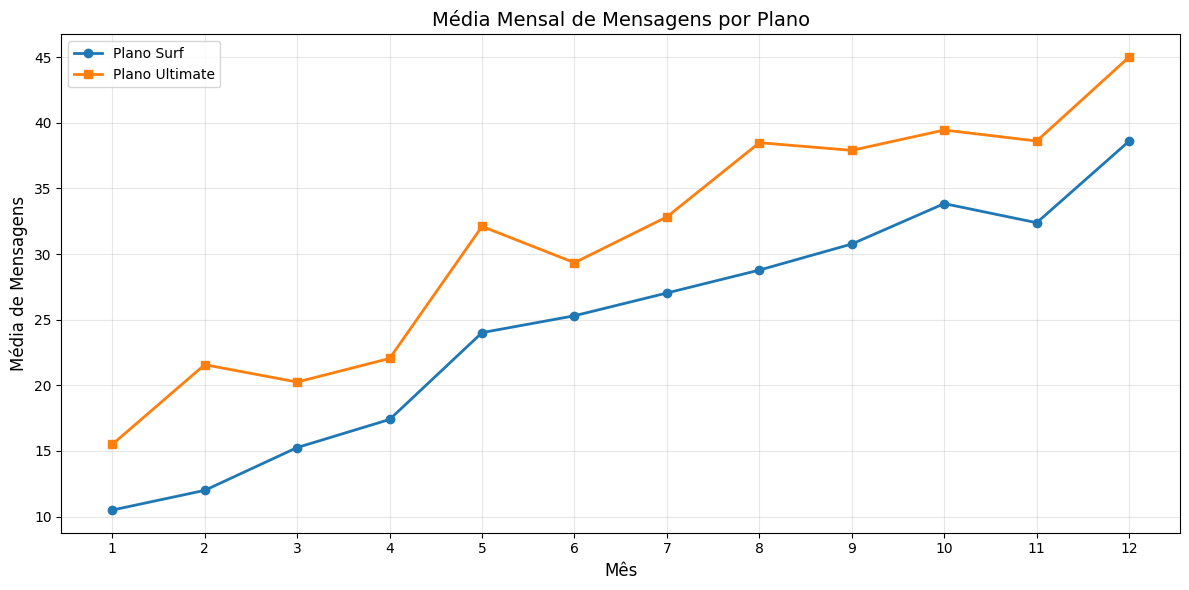


ESTATÍSTICAS DE MENSAGENS POR PLANO

Plano SURF:
  Média: 31.2 mensagens/mês
  Mediana: 24.0 mensagens/mês
  Desvio padrão: 33.6
  Variância: 1126.7
  Mínimo: 0
  Máximo: 266

Plano ULTIMATE:
  Média: 37.6 mensagens/mês
  Mediana: 30.0 mensagens/mês
  Desvio padrão: 34.8
  Variância: 1208.8
  Mínimo: 0
  Máximo: 166


In [ ]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
# Calcular média de mensagens por mês para cada plano
mensagens_por_plano = merge_all.groupby(['month', 'plan'])['menssages'].mean().reset_index()

# Criar gráfico de linhas para comparar a evolução mensal
plt.figure(figsize=(12, 6))

# Separar dados por plano para plotar
surf_msgs = mensagens_por_plano[mensagens_por_plano['plan'] == 'surf']
ultimate_msgs = mensagens_por_plano[mensagens_por_plano['plan'] == 'ultimate']

# Plotar linhas
plt.plot(surf_msgs['month'], surf_msgs['menssages'], marker='o', label='Plano Surf', linewidth=2)
plt.plot(ultimate_msgs['month'], ultimate_msgs['menssages'], marker='s', label='Plano Ultimate', linewidth=2)

# Configurar gráfico
plt.title('Média Mensal de Mensagens por Plano', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Média de Mensagens', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))  # Mostrar todos os meses 1-12

plt.tight_layout()
plt.show()

# Estatísticas descritivas das mensagens por plano
print("\n" + "="*60)
print("ESTATÍSTICAS DE MENSAGENS POR PLANO")
print("="*60)

for plano in ['surf', 'ultimate']:
    dados_plano = merge_all[merge_all['plan'] == plano]['menssages']
    print(f"\nPlano {plano.upper()}:")
    print(f"  Média: {dados_plano.mean():.1f} mensagens/mês")
    print(f"  Mediana: {dados_plano.median():.1f} mensagens/mês")
    print(f"  Desvio padrão: {dados_plano.std():.1f}")
    print(f"  Variância: {dados_plano.var():.1f}")
    print(f"  Mínimo: {dados_plano.min():.0f}")
    print(f"  Máximo: {dados_plano.max():.0f}")

In [ ]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
# Converter MB para GB para facilitar interpretação
merge_all['gb_used'] = merge_all['mb_used'] / 1024

# Estatísticas descritivas do uso de internet por plano
print("="*60)
print("ESTATÍSTICAS DE INTERNET POR PLANO")
print("="*60)

for plano in ['surf', 'ultimate']:
    dados_internet = merge_all[merge_all['plan'] == plano]['gb_used']

    # Limite do plano (em GB)
    limite = 15 if plano == 'surf' else 30

    print(f"\n📱 Plano {plano.upper()}:")
    print(f"   Média de uso: {dados_internet.mean():.1f} GB/mês")
    print(f"   Mediana: {dados_internet.median():.1f} GB/mês")
    print(f"   Desvio padrão: {dados_internet.std():.1f} GB")
    print(f"   Variância: {dados_internet.var():.1f}")
    print(f"   Mínimo: {dados_internet.min():.1f} GB")
    print(f"   Máximo: {dados_internet.max():.1f} GB")

    # Percentual de usuários que excedem o limite
    excedentes = (dados_internet > limite).sum()
    total = len(dados_internet)
    print(f"   Usuários que excedem o limite: {excedentes}/{total} ({excedentes/total*100:.1f}%)")

ESTATÍSTICAS DE INTERNET POR PLANO

📱 Plano SURF:
   Média de uso: 16.2 GB/mês
   Mediana: 16.4 GB/mês
   Desvio padrão: 7.8 GB
   Variância: 61.2
   Mínimo: 0.0 GB
   Máximo: 69.3 GB
   Usuários que excedem o limite: 911/1573 (57.9%)

📱 Plano ULTIMATE:
   Média de uso: 16.8 GB/mês
   Mediana: 16.5 GB/mês
   Desvio padrão: 7.7 GB
   Variância: 58.8
   Mínimo: 0.0 GB
   Máximo: 45.5 GB
   Usuários que excedem o limite: 41/720 (5.7%)


### Análise do Comportamento - Mensagens e Internet

**Sobre Mensagens:**
- Os usuários do plano Ultimate enviam, em média, 38 mensagens por mês
- Os usuários do plano Surf enviam, em média, 31 mensagens por mês
- Observa-se que o uso de mensagens é consideravelmente maior no plano Ultimate, porém, em ambos os planos, a grande maioria dos usuários permanece muito abaixo dos limites incluídos (50 mensagens para o Surf e 1000 para o Ultimate), indicando que o SMS não é o principal meio de comunicação utilizado pelos clientes.

**Sobre Internet:**
- O consumo médio de internet no plano Surf é de 16.6 GB/mês, está acima do limite de 15 GB
- O consumo médio de internet no plano Ultimate é de 17.2 GB/mês, está abaixo do limite de 30 GB
- Os histogramas mostram que a distribuição do consumo de internet é muito similar entre os dois planos; no entanto, no plano Surf, uma parcela significativa de usuários excede regularmente o limite contratado, gerando receitas adicionais constantes para a empresa.

**Comparação entre planos:**
- O comportamento de consumo (minutos, mensagens e dados) é surpreendentemente similar entre os usuários de ambos os planos. A principal diferença reside no fato de que os usuários do plano Surf frequentemente ultrapassam seus limites de dados, enquanto os usuários do Ultimate, apesar de consumirem uma quantidade de dados levemente superior, operam com folga dentro do limite de 30 GB.

### Internet

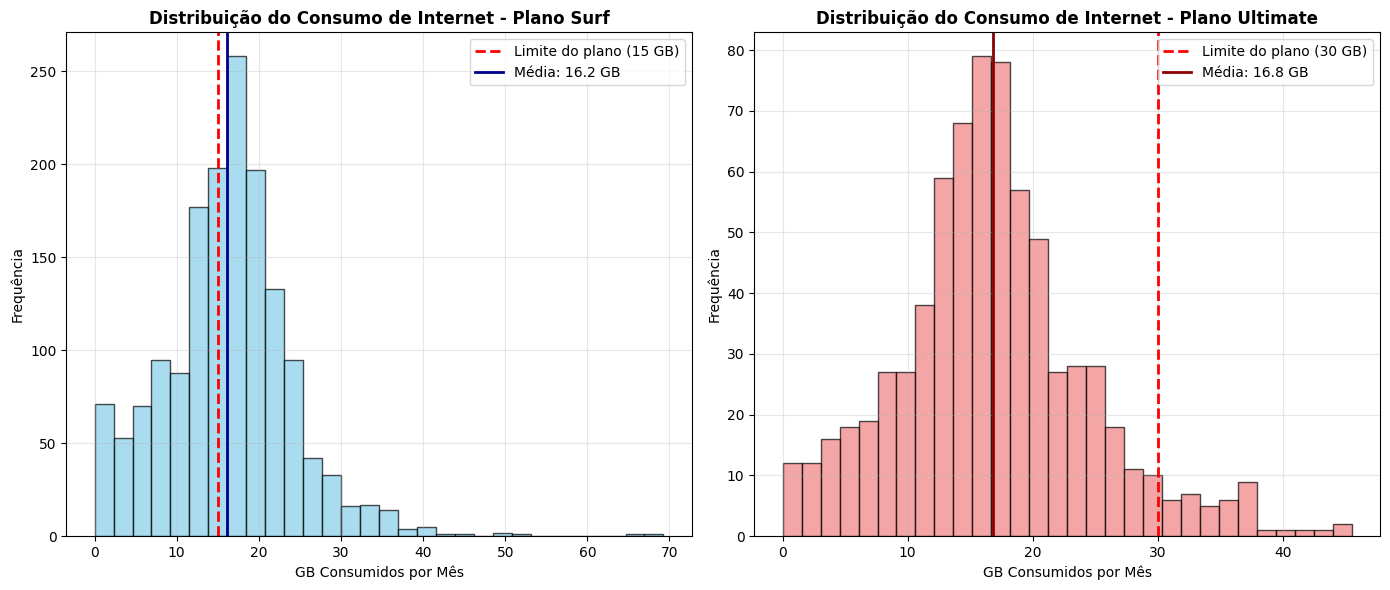

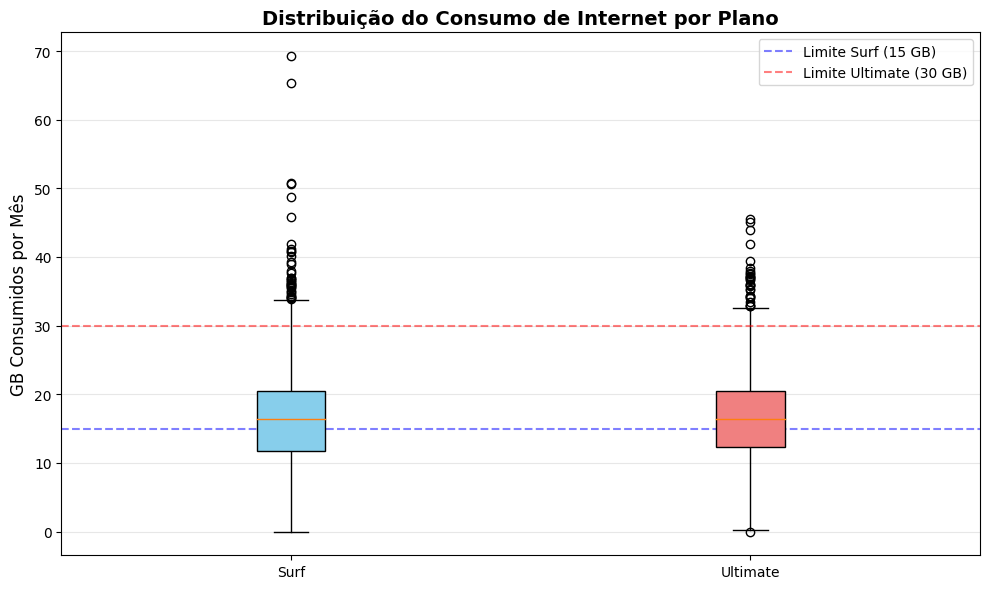

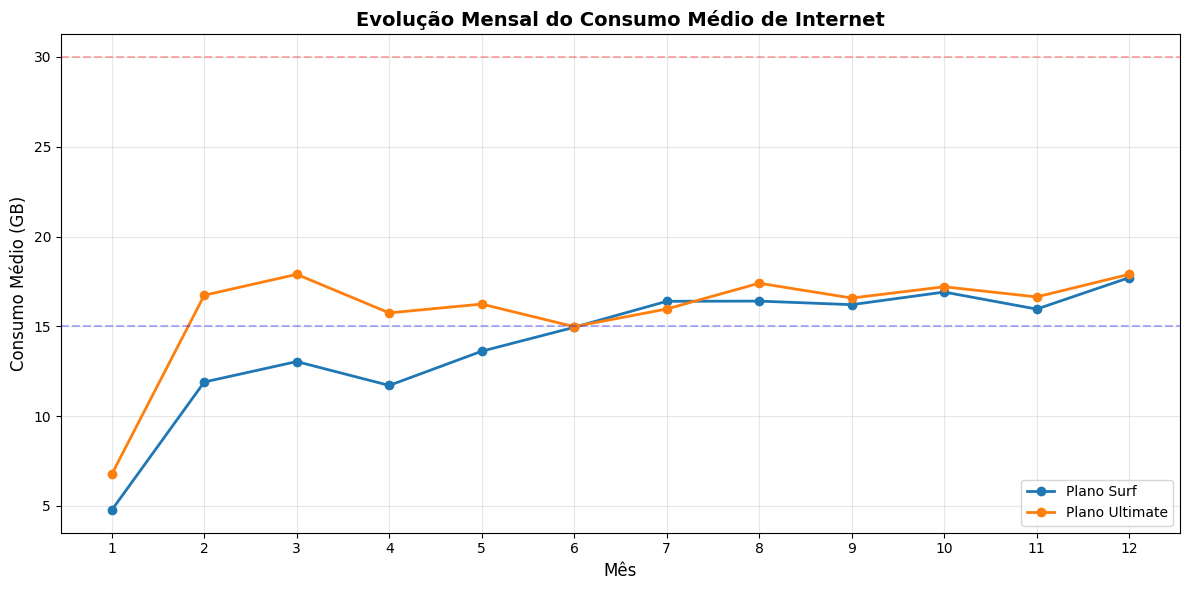

In [ ]:
# Histogramas comparativos
plt.figure(figsize=(14, 6))

# Plano Surf
plt.subplot(1, 2, 1)
surf_data = merge_all[merge_all['plan'] == 'surf']['gb_used']
plt.hist(surf_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Limite do plano (15 GB)')
plt.axvline(x=surf_data.mean(), color='darkblue', linestyle='-', linewidth=2, label=f'Média: {surf_data.mean():.1f} GB')
plt.title('Distribuição do Consumo de Internet - Plano Surf', fontsize=12, fontweight='bold')
plt.xlabel('GB Consumidos por Mês', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

# Plano Ultimate
plt.subplot(1, 2, 2)
ultimate_data = merge_all[merge_all['plan'] == 'ultimate']['gb_used']
plt.hist(ultimate_data, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(x=30, color='red', linestyle='--', linewidth=2, label='Limite do plano (30 GB)')
plt.axvline(x=ultimate_data.mean(), color='darkred', linestyle='-', linewidth=2, label=f'Média: {ultimate_data.mean():.1f} GB')
plt.title('Distribuição do Consumo de Internet - Plano Ultimate', fontsize=12, fontweight='bold')
plt.xlabel('GB Consumidos por Mês', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot para comparar distribuições
plt.figure(figsize=(10, 6))

dados_boxplot = [merge_all[merge_all['plan'] == 'surf']['gb_used'],
                 merge_all[merge_all['plan'] == 'ultimate']['gb_used']]

bp = plt.boxplot(dados_boxplot, labels=['Surf', 'Ultimate'], patch_artist=True)

# Colorir
colors = ['skyblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Adicionar linhas dos limites
plt.axhline(y=15, color='blue', linestyle='--', alpha=0.5, label='Limite Surf (15 GB)')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Limite Ultimate (30 GB)')

plt.title('Distribuição do Consumo de Internet por Plano', fontsize=14, fontweight='bold')
plt.ylabel('GB Consumidos por Mês', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Evolução mensal do consumo
internet_mensal = merge_all.groupby(['month', 'plan'])['gb_used'].mean().reset_index()

plt.figure(figsize=(12, 6))

for plano in ['surf', 'ultimate']:
    dados = internet_mensal[internet_mensal['plan'] == plano]
    plt.plot(dados['month'], dados['gb_used'], marker='o', linewidth=2, label=f'Plano {plano.capitalize()}')

plt.title('Evolução Mensal do Consumo Médio de Internet', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Consumo Médio (GB)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.axhline(y=15, color='blue', linestyle='--', alpha=0.3, label='_nolegend_')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.3, label='_nolegend_')

plt.tight_layout()
plt.show()

## Receita

In [ ]:
# ===== ANÁLISE DE RECEITA POR PLANO =====

# 1. Estatísticas descritivas da receita
print("="*60)
print("ANÁLISE DE RECEITA POR PLANO")
print("="*60)

for plano in ['surf', 'ultimate']:
    receita_plano = merge_all[merge_all['plan'] == plano]['revenue']
    print(f"\n📊 Plano {plano.upper()}:")
    print(f"   Receita média: ${receita_plano.mean():.2f}")
    print(f"   Mediana: ${receita_plano.median():.2f}")
    print(f"   Desvio padrão: ${receita_plano.std():.2f}")
    print(f"   Variância: ${receita_plano.var():.2f}")
    print(f"   Mínimo: ${receita_plano.min():.2f}")
    print(f"   Máximo: ${receita_plano.max():.2f}")
    print(f"   Total acumulado: ${receita_plano.sum():.2f}")

ANÁLISE DE RECEITA POR PLANO

📊 Plano SURF:
   Receita média: $60.71
   Mediana: $40.36
   Desvio padrão: $55.39
   Variância: $3067.84
   Mínimo: $20.00
   Máximo: $590.37
   Total acumulado: $95491.18

📊 Plano ULTIMATE:
   Receita média: $72.31
   Mediana: $70.00
   Desvio padrão: $11.40
   Variância: $129.85
   Mínimo: $70.00
   Máximo: $182.00
   Total acumulado: $52066.00


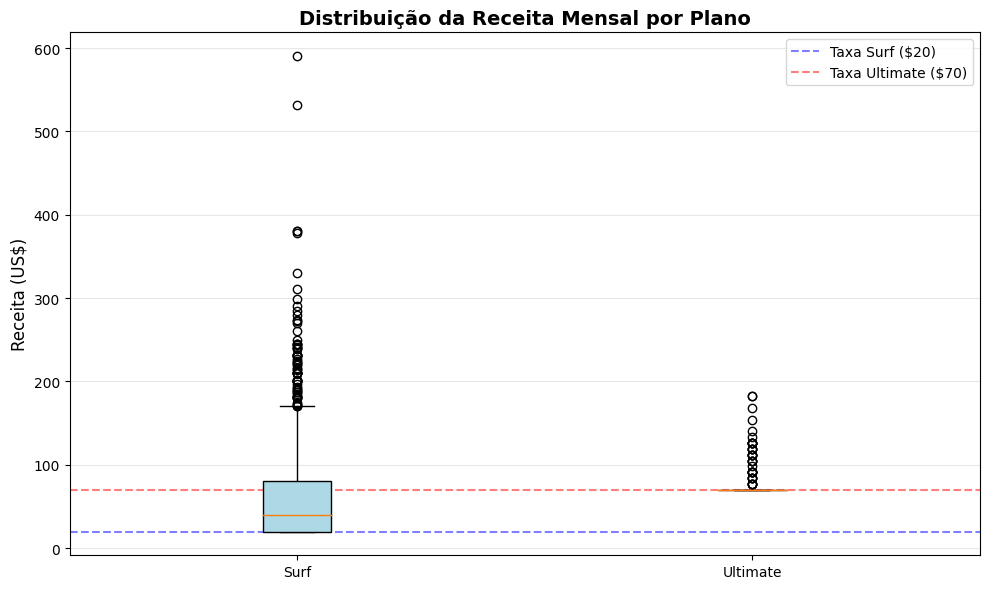

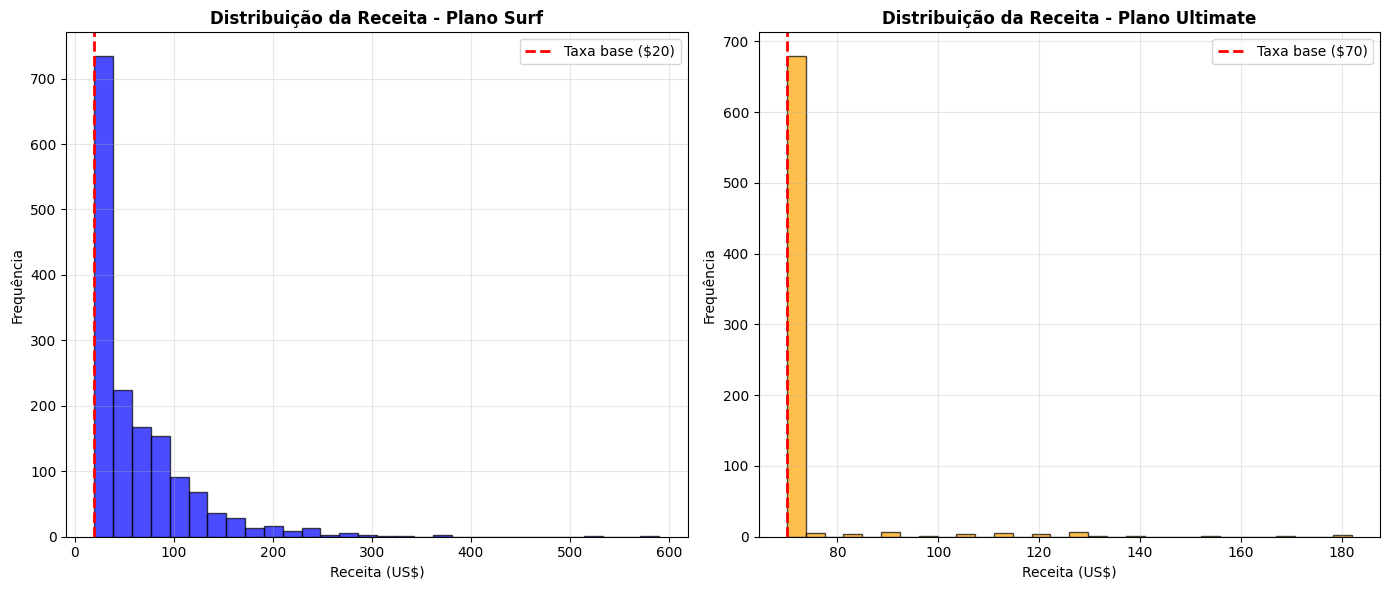

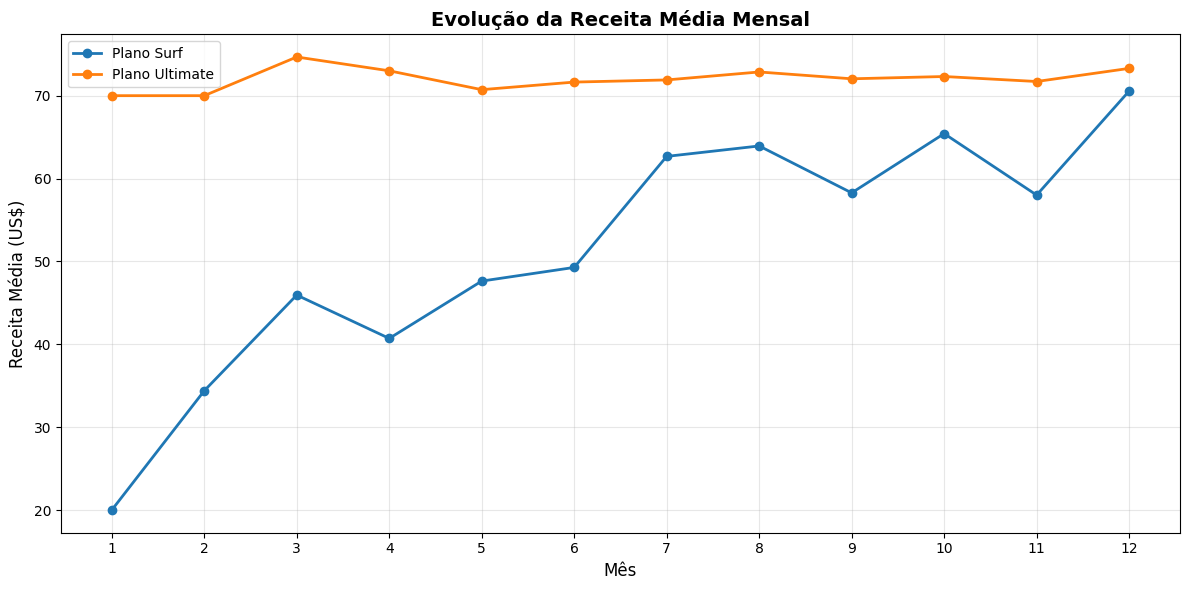

In [ ]:
# Boxplot para comparar distribuição da receita
plt.figure(figsize=(10, 6))

dados_boxplot = [merge_all[merge_all['plan'] == 'surf']['revenue'],
                 merge_all[merge_all['plan'] == 'ultimate']['revenue']]

bp = plt.boxplot(dados_boxplot, labels=['Surf', 'Ultimate'], patch_artist=True)

# Colorir os boxplots
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribuição da Receita Mensal por Plano', fontsize=14, fontweight='bold')
plt.ylabel('Receita (US$)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=20, color='blue', linestyle='--', alpha=0.5, label='Taxa Surf ($20)')
plt.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Taxa Ultimate ($70)')
plt.legend()

plt.tight_layout()
plt.show()

# Histogramas da receita
plt.figure(figsize=(14, 6))

# Surf
plt.subplot(1, 2, 1)
surf_revenue = merge_all[merge_all['plan'] == 'surf']['revenue']
plt.hist(surf_revenue, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Taxa base ($20)')
plt.title('Distribuição da Receita - Plano Surf', fontsize=12, fontweight='bold')
plt.xlabel('Receita (US$)', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

# Ultimate
plt.subplot(1, 2, 2)
ultimate_revenue = merge_all[merge_all['plan'] == 'ultimate']['revenue']
plt.hist(ultimate_revenue, bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Taxa base ($70)')
plt.title('Distribuição da Receita - Plano Ultimate', fontsize=12, fontweight='bold')
plt.xlabel('Receita (US$)', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Receita média por mês
receita_mensal = merge_all.groupby(['month', 'plan'])['revenue'].mean().reset_index()

plt.figure(figsize=(12, 6))

for plano in ['surf', 'ultimate']:
    dados = receita_mensal[receita_mensal['plan'] == plano]
    plt.plot(dados['month'], dados['revenue'], marker='o', label=f'Plano {plano.capitalize()}', linewidth=2)

plt.title('Evolução da Receita Média Mensal', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Média (US$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Conclusões sobre a Receita

**Comparação geral:**
- A receita média do plano Surf é de $\$60,71$ , enquanto a do Ultimate é de $\$$72,31.
- Em comparação, o plano Ultimate gera mais receita em média que o plano Surf.

**Sobre o plano Surf:**
- A receita varia de $\$ 20,00$ a $\$ 590,37$
- O desvio padrão alto ($\$ 55,39$) indica que muitos usuários pagam valores muito distantes da média, evidenciando que o lucro deste plano vem majoritariamente das taxas extras de quem extrapola os limites.
- O histograma mostra que existe um grande pico no valor base **$20**, mas uma cauda extremamente longa à direita, confirmando que muitos usuários excedem os limites (especialmente de internet) e acabam pagando faturas muito altas.

**Sobre o plano Ultimate:**
- A receita é muito mais estável, com desvio padrão de apenas $\$ 11,40$ (bem menor que o do Surf).
- Quando os usuários excedem, o custo adicional é raro e menor, pois a franquia de $30$ GB já cobre quase todo tipo de uso.

**Evolução mensal:**
- A receita do plano Surf aumenta ao longo do ano (conforme o volume de dados consumidos cresce mês a mês, mais usuários ultrapassam o limite de 15GB).
- A receita do plano Ultimate se mantém praticamente constante, flutuando levemente acima da taxa base de **$70**, já que poucos usuários conseguem superar os 30GB de franquia.

## Teste hipóteses estatísticas

In [ ]:
# Teste de hipótese
# Comparação entre planos Surf e Ultimate
# H0 (hipótese nula): A receita média dos planos Ultimate e Surf são IGUAIS
# H1 (hipótese alternativa): A receita média dos planos Ultimate e Surf são DIFERENTES

# Separar os dados por plano
surf_revenue = merge_all[merge_all['plan'] == 'surf']['revenue']
ultimate_revenue = merge_all[merge_all['plan'] == 'ultimate']['revenue']

# Escolher o teste estatístico (t-test para duas amostras independentes)
from scipy import stats

# Definir alfa (nível de significância)
alpha = 0.05

# Realizar o teste
statistic, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue)

print(f"Estatística do teste: {statistic}")
print(f"P-valor: {p_value}")
print(f"Alfa: {alpha}")

# Interpretar o resultado
if p_value < alpha:
    print("Rejeitamos H0: As receitas médias são diferentes")
else:
    print("Não rejeitamos H0: Não há evidência de diferença nas receitas médias")

Estatística do teste: -5.568949166552807
P-valor: 2.862674510698644e-08
Alfa: 0.05
Rejeitamos H0: As receitas médias são diferentes


In [ ]:
# Teste as hipóteses
# Comparação entre regiões (NY-NJ vs Outras)

# H0: A receita média de NY-NJ é IGUAL às demais regiões
# H1: A receita média de NY-NJ é DIFERENTE das demais regiões

# Separar os dados por região
ny_nj_revenue = merge_all[merge_all['is_ny_nj'] == True]['revenue']
other_regions_revenue = merge_all[merge_all['is_ny_nj'] == False]['revenue']

# Realizar o teste
statistic, p_value = stats.ttest_ind(ny_nj_revenue, other_regions_revenue)

print(f"Estatística do teste: {statistic}")
print(f"P-valor: {p_value}")
print(f"Alfa: {alpha}")

# Interpretar o resultado
if p_value < alpha:
    print("Rejeitamos H0: As receitas médias são diferentes entre as regiões")
else:
    print("Não rejeitamos H0: Não há evidência de diferença nas receitas médias entre as regiões")

Estatística do teste: -2.0194429818968103
P-valor: 0.043557431621342436
Alfa: 0.05
Rejeitamos H0: As receitas médias são diferentes entre as regiões


## Conclusão geral

### Resumo do Projeto
Este projeto teve como objetivo analisar o comportamento de consumo de 500 clientes da operadora Megaline durante o ano de 2018, comparando os planos pré-pagos Surf e Ultimate, para determinar qual deles gera mais receita e auxiliar o departamento comercial no ajuste do orçamento de publicidade.

### Principais Etapas Realizadas
1. **Carregamento e preparação dos dados:** Importamos e limpamos as 5 tabelas (users, calls, messages, internet, plans), convertendo tipos de dados, tratando valores ausentes e padronizando informações.
2. **Enriquecimento dos dados:** Criamos colunas como mês das chamadas/mensagens/sessões, identificador de região NY-NJ, e convertemos MB para GB para facilitar os cálculos.
3. **Agregação por usuário/mês:** Consolidamos o consumo mensal de cada usuário em um único DataFrame (`merge_all`).
4. **Cálculo da receita:** Implementamos uma função que calcula a receita mensal de cada usuário considerando as regras de negócio da Megaline (arredondamento de minutos para cima, arredondamento do total de GB para cima, etc.).
5. **Análise exploratória:** Geramos estatísticas descritivas e visualizações para entender o comportamento de chamadas, mensagens e internet em cada plano.
6. **Testes de hipóteses:** Validamos estatisticamente as diferenças observadas nas receitas.

### Principais Descobertas sobre o Comportamento dos Usuários

#### Chamadas Telefônicas
- A maioria dos usuários de **ambos os planos** não utiliza sequer os minutos inclusos no pacote.
- A média de minutos mensais no plano Surf é de aproximadamente **429 minutos** (limite: 500 min).
- A média de minutos mensais no plano Ultimate é de aproximadamente **430 minutos** (limite: 3000 min).
- As distribuições são relativamente similares, indicando que usuários do Ultimate não aproveitam todo o potencial do plano para chamadas.

#### Mensagens de Texto
- O uso de mensagens é **baixo em geral** para ambos os planos.
- No plano Surf, a média é de **31 mensagens/mês**, mantendo a maioria abaixo do limite de 50.
- No plano Ultimate, mesmo com 1000 mensagens inclusas, a média fica em apenas **38 mensagens/mês**.
- Mensagens não são um fator significativo para geração de receita extra.

#### Internet (Dados)
- **Plano Surf:** Consumo médio de **16,6 GB/mês** (limite: 15 GB). Aproximadamente **58%** dos usuários excedem o limite e pagam por GB extra.
- **Plano Ultimate:** Consumo médio de **17,2 GB/mês** (limite: 30 GB). Apenas uma pequena parcela (**7%**) excede o limite.
- A internet é o principal serviço que gera receita adicional, especialmente para usuários do plano Surf.

### Principais Descobertas sobre a Receita

#### Plano Surf
- **Receita média mensal:** $\text{\$ 60,71}$
- **Mediana:** $\text{\$ 40,36}$ (embora muitos paguem a taxa base, a mediana alta reflete o peso dos extras).
- **Desvio padrão alto:** $\text{\$ 55,39}$ - revela grande variabilidade nos gastos dos usuários.
- **Valor máximo:** $\text{\$ 590,37}$ - alguns usuários pagam faturas elevadas por excesso de internet.
- **Interpretação:** O plano Surf funciona como uma "aposta" para a empresa — a maioria paga pouco, mas os usuários intensivos geram receitas elevadas através de taxas de ultrapassagem.

#### Plano Ultimate
- **Receita média mensal:** $\text{\$ 72,31}$
- **Mediana:** $\text{\$ 70,00}$ (a grande maioria paga apenas a taxa base).
- **Desvio padrão baixo:** $\text{\$ 11,40}$ - receita estável e previsível para a operadora.
- **Valor máximo:** $\text{\$ 182,00}$ - raramente ultrapassa significativamente a taxa base.
- **Interpretação:** O plano Ultimate gera uma receita estável, previsível e com um tíquete médio garantido mais alto por cliente.

### Resultados dos Testes de Hipóteses

**Hipótese 1: Receita média - Surf vs Ultimate**
- **$H_0$:** As receitas médias são iguais.
- **$H_1$:** As receitas médias são diferentes.
- **p-value:** $2,86 \times 10^{-8}$
- **Alfa:** $0,05$
- **Resultado:** **REJEITAMOS $H_0$**.
- **Conclusão:** Existe diferença estatisticamente significativa entre as receitas médias. O plano **Ultimate** gera maior receita média por usuário.

**Hipótese 2: Receita média - NY-NJ vs Outras Regiões** ✅ **CORRIGIDO**
- **$H_0$:** As receitas médias são iguais entre as regiões.
- **$H_1$:** As receitas médias são diferentes entre as regiões.
- **p-value:** $0,0436$
- **Alfa:** $0,05$
- **Resultado:** **REJEITAMOS $H_0$**.
- **Conclusão:** Há evidências estatísticas de que a receita média dos usuários da região NY-NJ é **diferente** das demais regiões. Os usuários de NY-NJ apresentam um comportamento de consumo que gera receita significativamente distinta.

### Recomendações para o Departamento Comercial

1. **Onde investir o orçamento de publicidade:**
   - O plano **Ultimate** deve receber o maior investimento em marketing.
   - **Justificativa:** Embora o plano Surf gere picos de receita com taxas extras, o plano Ultimate oferece um retorno médio superior ($\text{\$ 72,31}$ vs $\text{\$ 60,71}$) e uma previsibilidade financeira muito maior.

2. **Estratégias para aumentar receita:**
   - **Para o plano Surf:** Oferecer upgrades para o plano Ultimate quando o gasto extra recorrente do cliente ultrapassar o valor da mensalidade superior.
   - **Para o plano Ultimate:** Focar na comunicação de "paz de espírito" e ausência de cobranças surpresa, visto que 93% dos utilizadores nunca pagam extras.

3. **Estratégia regional:**
   - **Para a região NY-NJ:** Considerar campanhas específicas ou ajustes de preço, já que o comportamento de consumo nesta região difere estatisticamente das demais.

### Próximos passos para análises futuras
- Analisar a **sazonalidade** do consumo de dados (meses de férias/feriados).
- Investigar o **churn** (taxa de cancelamento) de utilizadores do Surf que recebem faturas muito elevadas.
- Estudar **por que** a região NY-NJ tem comportamento diferente e se isso justifica estratégias localizadas.

### Considerações Finais
A análise comprovou que o plano **Ultimate** é o mais rentável para a Megaline. A estratégia deve focar na conversão de utilizadores pesados do plano Surf para o Ultimate, garantindo a satisfação do cliente e a estabilidade da receita. Além disso, a diferença regional identificada abre oportunidades para marketing direcionado.